# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nfl_data_py as nfl

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import xgboost as xgb
import shap
import optuna

from ELO import ELO

/Users/iggysiegel/opt/anaconda3/envs/sports_betting/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Import Data

In [2]:
data = pd.read_csv("data/data_engineering_2008_2024_15.csv")
data = data[data["season"] != 2010] # Drop first season due to data engineering

/var/folders/4p/33lbnggs2vz1ffh9zv619nnm0000gn/T/ipykernel_16233/149168617.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/data_engineering_2008_2024_15.csv")


In [3]:
features = [
    # General
    'home_elo_prob',
    'div_game',
    'is_playoff',
    'week',
    'away_rest',
    'home_rest',

    # Offense - Home
    'current_win_pctg_home',
    'last_win_pctg_home',
    'streak_home',
    'ats_pctg_home',
    'spread_differential_home',
    'drive_scoring_percentage_off_home',
    'qbr_home',
    'posteam_score_max_off_home',
    'yards_gained_sum_off_home',
    'total_time_of_posession_off_home',
    'total_plays_off_home',
    'complete_pass_sum_off_home',
    'passing_yards_sum_off_home',
    'pass_touchdown_sum_off_home',
    'rush_attempt_sum_off_home',
    'rushing_yards_sum_off_home',
    'rush_touchdown_sum_off_home',
    'third_down_conversion_rate_off_home',
    'penalty_yards_sum_off_home',
    'fumble_lost_sum_off_home',
    'net_turnovers_off_home',
    'qb_hit_sum_off_home',
    'sack_sum_off_home',
    'epa_sum_off_home',

    # Defense - Home
    'posteam_score_max_def_home',
    'yards_gained_sum_def_home',
    'total_plays_def_home',
    'fumble_lost_sum_def_home',
    'net_turnovers_def_home',
    'third_down_conversion_rate_def_home',
    'passing_yards_sum_def_home',
    'pass_touchdown_sum_def_home',
    'rushing_yards_sum_def_home',
    'rush_touchdown_sum_def_home',
    'qb_hit_sum_def_home',
    'sack_sum_def_home',
    'epa_sum_def_home',

    # Offense - Away
    'current_win_pctg_away',
    'last_win_pctg_away',
    'streak_away',
    'ats_pctg_away',
    'spread_differential_away',
    'drive_scoring_percentage_off_away',
    'qbr_away',
    'posteam_score_max_off_away',
    'yards_gained_sum_off_away',
    'total_time_of_posession_off_away',
    'total_plays_off_away',
    'complete_pass_sum_off_away',
    'passing_yards_sum_off_away',
    'pass_touchdown_sum_off_away',
    'rush_attempt_sum_off_away',
    'rushing_yards_sum_off_away',
    'rush_touchdown_sum_off_away',
    'third_down_conversion_rate_off_away',
    'penalty_yards_sum_off_away',
    'fumble_lost_sum_off_away',
    'net_turnovers_off_away',
    'qb_hit_sum_off_away',
    'sack_sum_off_away',
    'epa_sum_off_away',

    # Defense - Away
    'posteam_score_max_def_away',
    'yards_gained_sum_def_away',
    'total_plays_def_away',
    'fumble_lost_sum_def_away',
    'net_turnovers_def_away',
    'third_down_conversion_rate_def_away',
    'passing_yards_sum_def_away',
    'pass_touchdown_sum_def_away',
    'rushing_yards_sum_def_away',
    'rush_touchdown_sum_def_away',
    'qb_hit_sum_def_away',
    'sack_sum_def_away',
    'epa_sum_def_away'
]

# XGBoost / Hyperparameter Tuning

In [4]:
def prepare_data(data, train_seasons, test_seasons, features):
    """
    Prepare data for training and testing.

    Inputs:
        - data: pd.DataFrame, data
        - features: list, features to use
        - train_seasons: list, seasons to train on
        - test_seasons: list, seasons to test on
    Outputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - X_train: pd.DataFrame, training features
        - y_train: pd.Series, training labels
        - X_test: pd.DataFrame, testing features
        - y_test: pd.Series, testing labels
    """
    train_data = data[data["season"].isin(train_seasons)].dropna(subset = features)
    test_data = data[data["season"].isin(test_seasons)].dropna(subset = features)
    
    X_train = train_data[features]
    y_train = train_data["result"]
    X_test = test_data[features]
    y_test = test_data["result"]

    return train_data, test_data, X_train, y_train, X_test, y_test

In [5]:
def objective(trial, X_train, y_train):
    """
    Objective function for Optuna to optimize XGBoost hyperparameters for regression.

    Inputs:
        - trial: Optuna trial object
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Continuous target labels
    Outputs:
        - score: float, Validation RMSE score
    """
    # Define the hyperparameter search space
    param_grid = {
        "max_depth": trial.suggest_int("max_depth", 1, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.1),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 0.5, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1, 0.5, 1.0, 5.0])
    }

    # Initialize the XGBoost model for regression
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = 10000,
        early_stopping_rounds = 10,
        **param_grid
    )

    # 5-fold cross validation
    kf = KFold(n_splits = 5)
    scores = []
    early_stopping = []
    for train_index, val_index in kf.split(X_train):
        X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
        y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
        model.fit(
            X_t,
            y_t,
            eval_set = [(X_v, y_v)],
            verbose = False
        )
        preds = model.predict(X_v)
        scores.append(metrics.root_mean_squared_error(y_v, preds))
        early_stopping.append(model.best_iteration)
    trial.set_user_attr("early_stopping", int(sum(early_stopping) / len(early_stopping)))

    # Return the mean validation RMSE
    return sum(scores) / len(scores)

In [6]:
def tune_hyperparameters(X_train, y_train, n_trials):
    """
    Run Optuna hyperparameter tuning.

    Inputs:
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Input labels
        - n_trials: int, Number of optimization trials
    Output:
        - study: Optuna study object
    """
    study = optuna.create_study(direction = "minimize")
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials = n_trials)
    return study

In [7]:
def betting_simulation(train_data, test_data, confidence = 1.0):
    """ 
    Simulate betting on games based on model predictions.

    Inputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
    Outputs:
        - overall_accuracy: float, overall accuracy of betting strategy
        - total_games: int, total number of games bet on
        
    The function evaluates betting outcomes by comparing model predictions to the spread lines. If the 
    difference between the model predictions and spread lines is greater than the threshold, the function
    bets on the game.
    """
    # Determine threshold for high-confidence bets
    threshold = confidence * np.std(train_data["difference"])

    # Initialize counters
    num_correct_total = 0
    num_incorrect_total = 0
    
    # Iterate through each week
    for week in test_data["week"].unique():
        week_data = test_data[test_data["week"] == week]
        num_correct_week = 0
        num_incorrect_week = 0
        for row in week_data.itertuples():
            if row.difference > threshold:
                if (
                    (row.predictions < row.spread_line and row.result < row.spread_line) or
                    (row.predictions > row.spread_line and row.result > row.spread_line)
                ):                    
                    num_correct_week += 1
                    num_correct_total += 1
                else:
                    num_incorrect_week += 1
                    num_incorrect_total += 1

        # Calculate and print weekly accuracy
        total_week_games = num_correct_week + num_incorrect_week
        if total_week_games > 0:
            weekly_accuracy = num_correct_week / total_week_games
            print(f"Week {week:<2}: {weekly_accuracy:.4f} ({num_correct_week}/{total_week_games})")

    # Calculate and print overall accuracy
    total_games = num_correct_total + num_incorrect_total
    if total_games > 0:
        overall_accuracy = num_correct_total / total_games
        print(f"\nSeason Accuracy: {overall_accuracy:.4f} ({num_correct_total}/{total_games})")

    return overall_accuracy, total_games

In [8]:
def main(data, train_seasons, test_seasons, features, n_trials = 100, confidence = 1.0, shapley = False):
    """ 
    Main function to train a machine learning model for NFL game predictions.

    This function prepares the data, tunes hyperparameters, trains the model, and simulates betting outcomes
    based on the model's predictions.

    Inputs:
        - data: pd.DataFrame, full dataset containing game data
        - train_seasons: list, seasons used for training the model
        - test_seasons: list, seasons used for testing the model
        - features: list, feature columns used for model training and predictions
        - n_trials: int, number of trials for hyperparameter optimization (default is 100)
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
        - shapley: bool, whether to plot SHAP values (default is False)
    Outputs:
        - train_data: pd.DataFrame, training data with model predictions
        - test_data: pd.DataFrame, testing data with model predictions
        - model: Fit XGBoost model
    """
    # Prepare data
    train_data, test_data, X_train, y_train, X_test, y_test = prepare_data(data, train_seasons, test_seasons, features)

    # Tune hyperparameters
    study = tune_hyperparameters(X_train, y_train, n_trials)
    print("Best Optuna parameters:", study.best_params)
    print("Best Optuna score:", study.best_value)
    print()

    # Fit the model with the best hyperparameters
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = study.best_trial.user_attrs["early_stopping"],
        **study.best_params
    )
    model.fit(X_train, y_train)

    # Store predictions and differences
    train_data["predictions"] = model.predict(X_train)
    train_data["difference"] = abs(train_data["predictions"] - train_data["spread_line"])
    test_data["predictions"] = model.predict(X_test)
    test_data["difference"] = abs(test_data["predictions"] - test_data["spread_line"])

    # Shapley plot
    if shapley:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)
        plt.figure(figsize = (20, 12))
        shap.summary_plot(shap_values, X_train, show = True, max_display = 20, plot_type = "violin")
        plt.show()

    # Betting simulation
    _, _ = betting_simulation(train_data, test_data, confidence)

    return train_data, test_data, model

# Performance

In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 200
CONFIDENCE = 0.0

### 2024

In [10]:
%%capture

train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
test_seasons = [2024]

train_data_2024, test_data_2024, model_2024 = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

res_2024 = []
for i in np.arange(0.0, 3.05, 0.05):
    accuracy, num_games = betting_simulation(train_data_2024, test_data_2024, i)
    res_2024.append((i, accuracy, num_games))

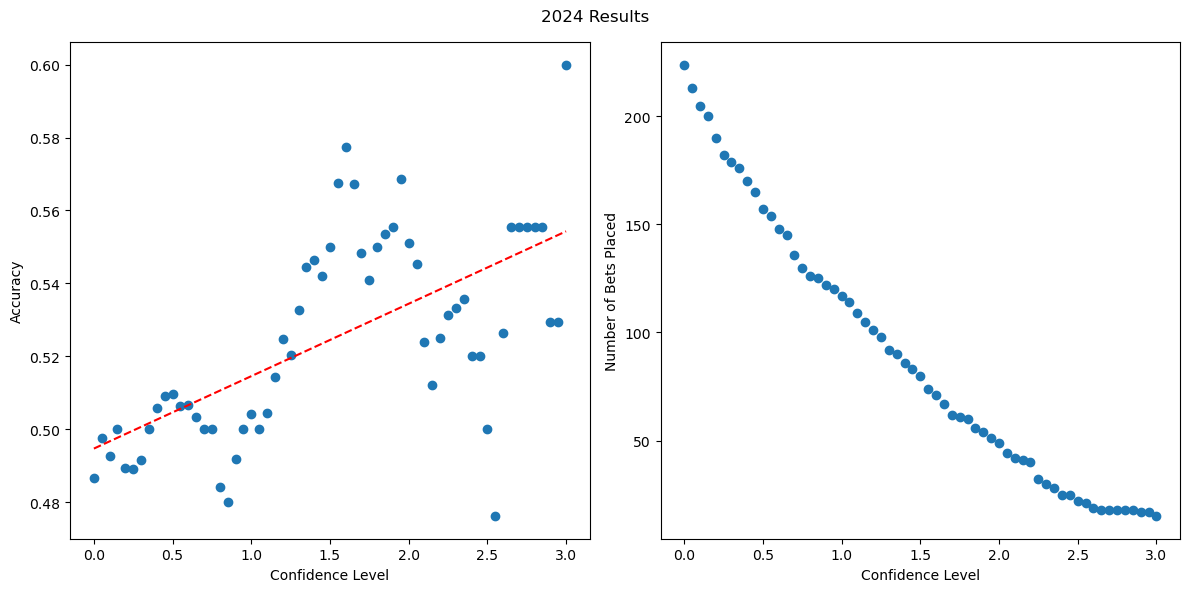

In [11]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = [x[0] for x in res_2024]
y_vals = [x[1] for x in res_2024]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--")

plt.subplot(1, 2, 2)
y_vals2 = [x[2] for x in res_2024]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed")

plt.suptitle("2024 Results")
plt.tight_layout()
plt.show()

### 2023

In [12]:
%%capture

train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
test_seasons = [2023]

train_data_2023, test_data_2023, model_2023 = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

res_2023 = []
for i in np.arange(0.0, 3.05, 0.05):
    accuracy, num_games = betting_simulation(train_data_2023, test_data_2023, i)
    res_2023.append((i, accuracy, num_games))

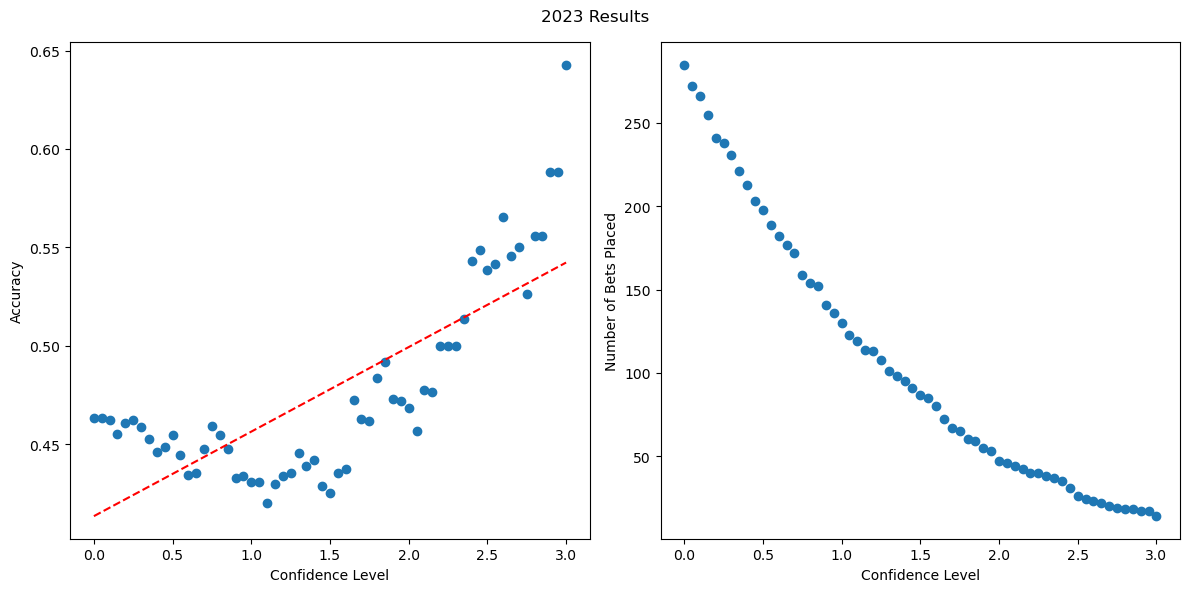

In [13]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = [x[0] for x in res_2023]
y_vals = [x[1] for x in res_2023]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--")

plt.subplot(1, 2, 2)
y_vals2 = [x[2] for x in res_2023]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed")

plt.suptitle("2023 Results")
plt.tight_layout()
plt.show()

### 2022

In [14]:
%%capture

train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_seasons = [2022]

train_data_2022, test_data_2022, model_2022 = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

res_2022 = []
for i in np.arange(0.0, 3.05, 0.05):
    accuracy, num_games = betting_simulation(train_data_2022, test_data_2022, i)
    res_2022.append((i, accuracy, num_games))

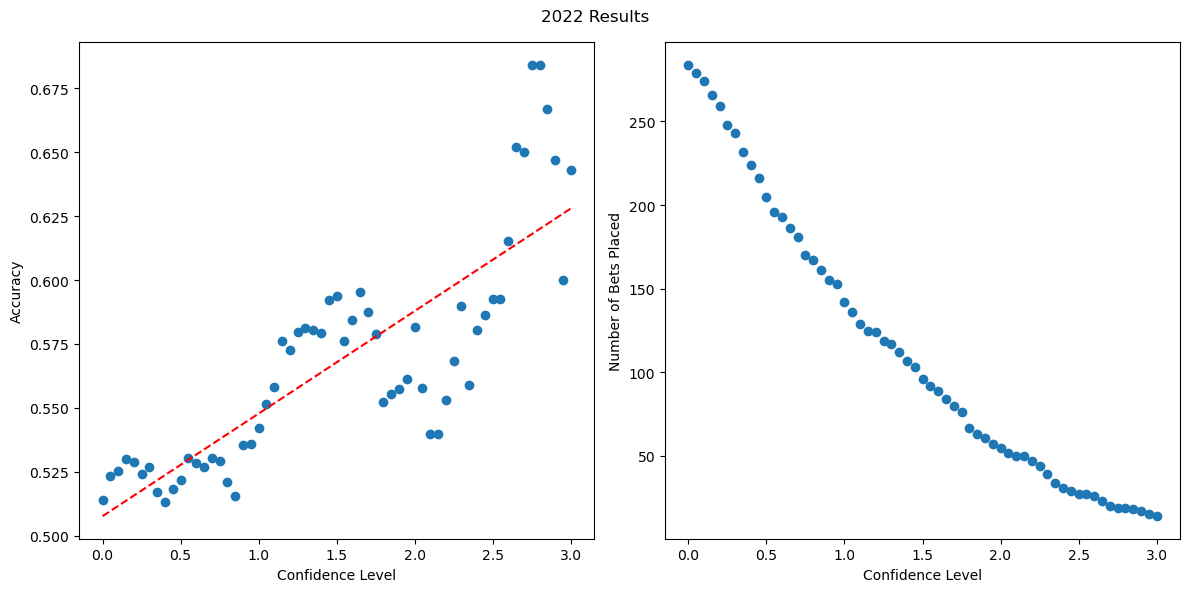

In [15]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = [x[0] for x in res_2022]
y_vals = [x[1] for x in res_2022]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--")

plt.subplot(1, 2, 2)
y_vals2 = [x[2] for x in res_2022]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed")

plt.suptitle("2022 Results")
plt.tight_layout()
plt.show()

### 2021

In [16]:
%%capture

train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
test_seasons = [2021]

train_data_2021, test_data_2021, model_2021 = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

res_2021 = []
for i in np.arange(0.0, 3.05, 0.05):
    accuracy, num_games = betting_simulation(train_data_2021, test_data_2021, i)
    res_2021.append((i, accuracy, num_games))

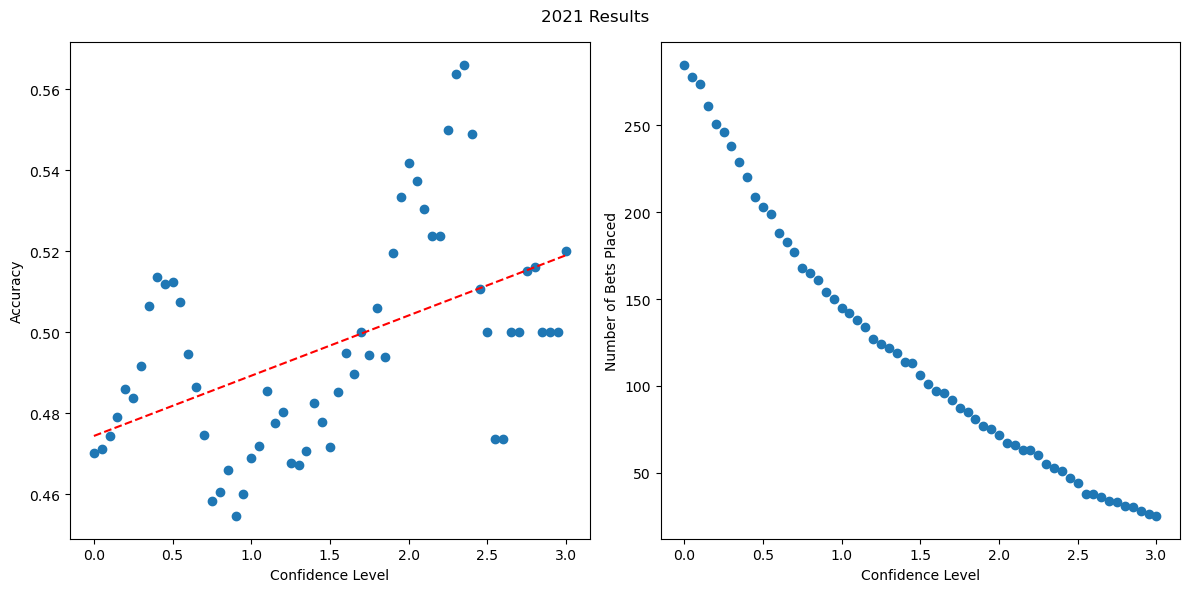

In [17]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = [x[0] for x in res_2021]
y_vals = [x[1] for x in res_2021]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--")

plt.subplot(1, 2, 2)
y_vals2 = [x[2] for x in res_2021]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed")

plt.suptitle("2021 Results")
plt.tight_layout()
plt.show()

### 2020

In [18]:
%%capture

train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
test_seasons = [2020]

train_data_2020, test_data_2020, model_2020 = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

res_2020 = []
for i in np.arange(0.0, 3.05, 0.05):
    accuracy, num_games = betting_simulation(train_data_2020, test_data_2020, i)
    res_2020.append((i, accuracy, num_games))

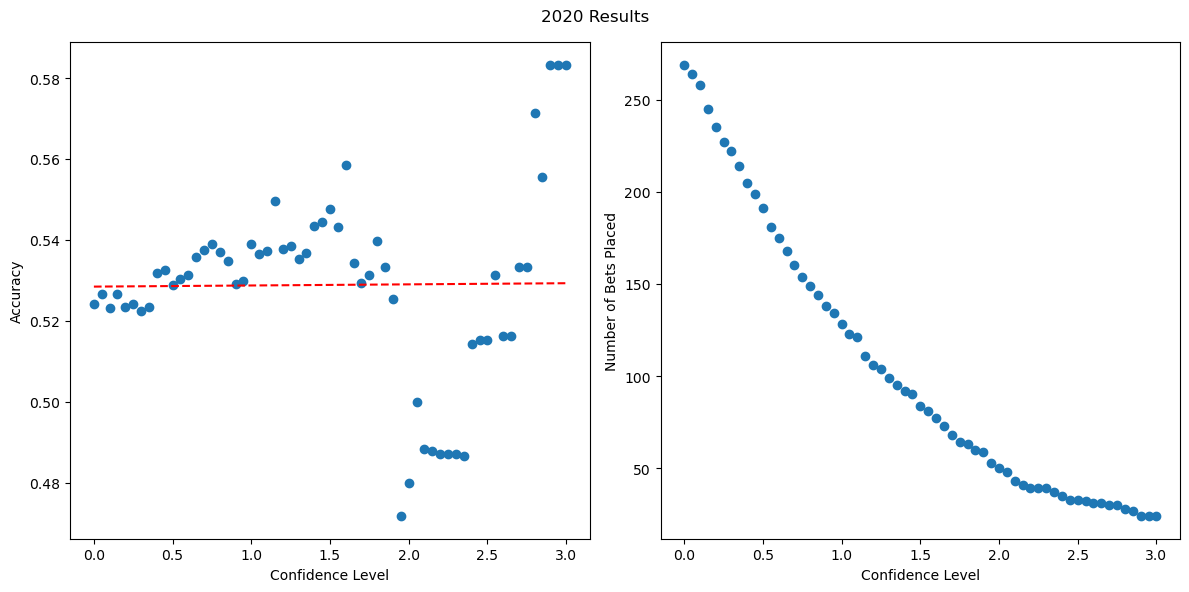

In [19]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = [x[0] for x in res_2020]
y_vals = [x[1] for x in res_2020]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--")

plt.subplot(1, 2, 2)
y_vals2 = [x[2] for x in res_2020]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed")

plt.suptitle("2020 Results")
plt.tight_layout()
plt.show()

### 2019

In [20]:
%%capture

train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
test_seasons = [2019]

train_data_2019, test_data_2019, model_2019 = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

res_2019 = []
for i in np.arange(0.0, 3.05, 0.05):
    accuracy, num_games = betting_simulation(train_data_2019, test_data_2019, i)
    res_2019.append((i, accuracy, num_games))

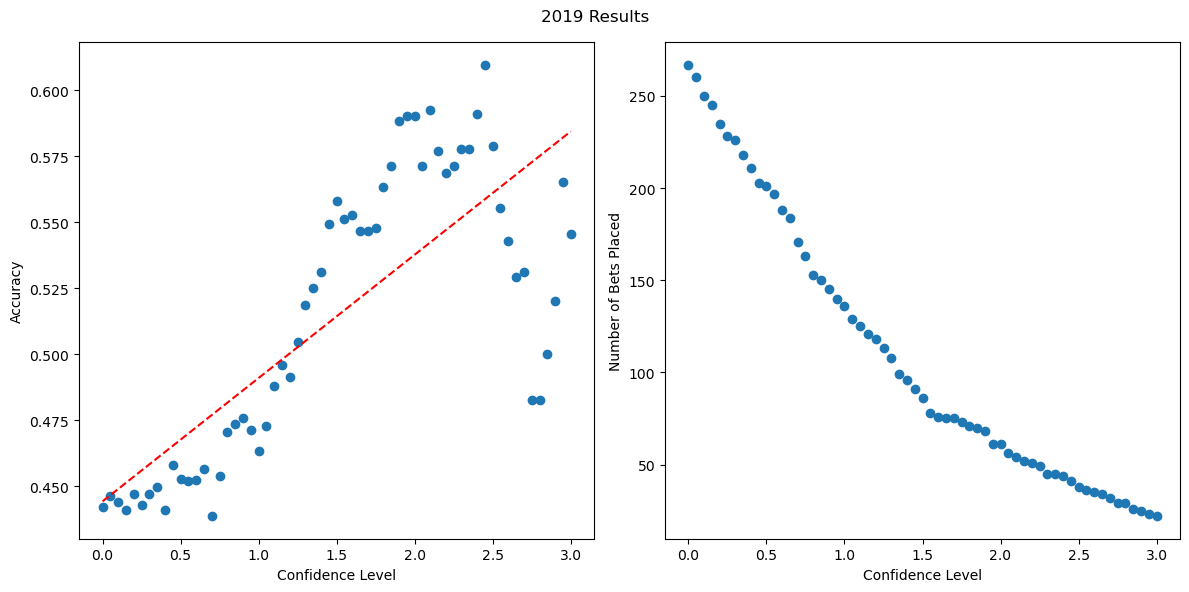

In [21]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = [x[0] for x in res_2019]
y_vals = [x[1] for x in res_2019]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--")

plt.subplot(1, 2, 2)
y_vals2 = [x[2] for x in res_2019]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed")

plt.suptitle("2019 Results")
plt.tight_layout()
plt.show()

### 2018

In [22]:
%%capture

train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017]
test_seasons = [2018]

train_data_2018, test_data_2018, model_2018 = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

res_2018 = []
for i in np.arange(0.0, 3.05, 0.05):
    accuracy, num_games = betting_simulation(train_data_2018, test_data_2018, i)
    res_2018.append((i, accuracy, num_games))

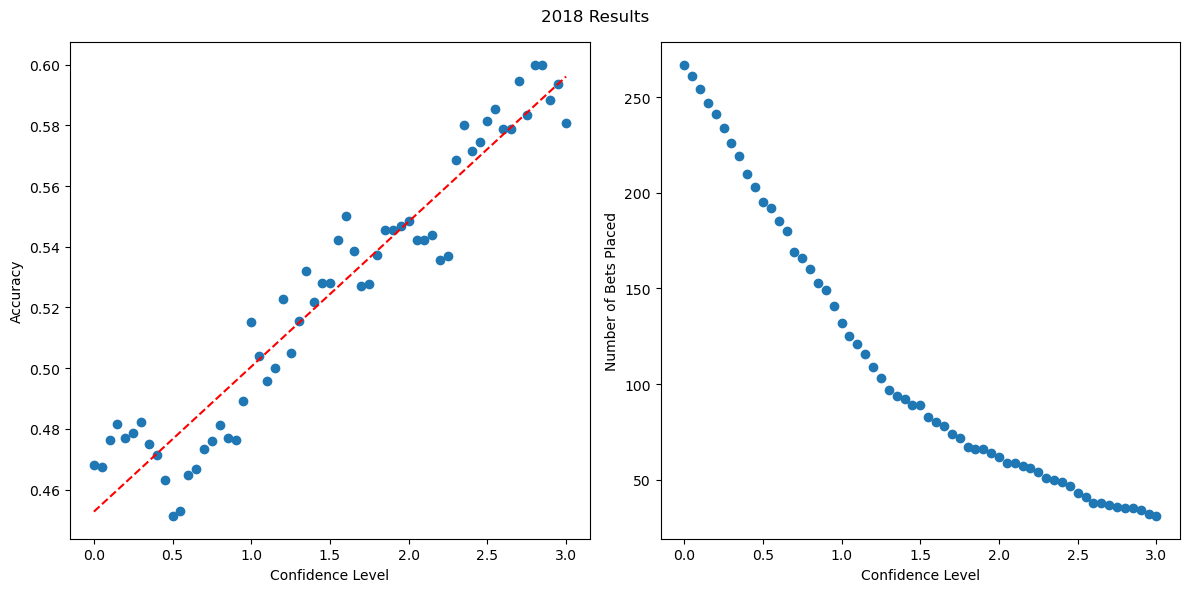

In [23]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = [x[0] for x in res_2018]
y_vals = [x[1] for x in res_2018]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--")

plt.subplot(1, 2, 2)
y_vals2 = [x[2] for x in res_2018]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed")

plt.suptitle("2018 Results")
plt.tight_layout()
plt.show()

### Overall

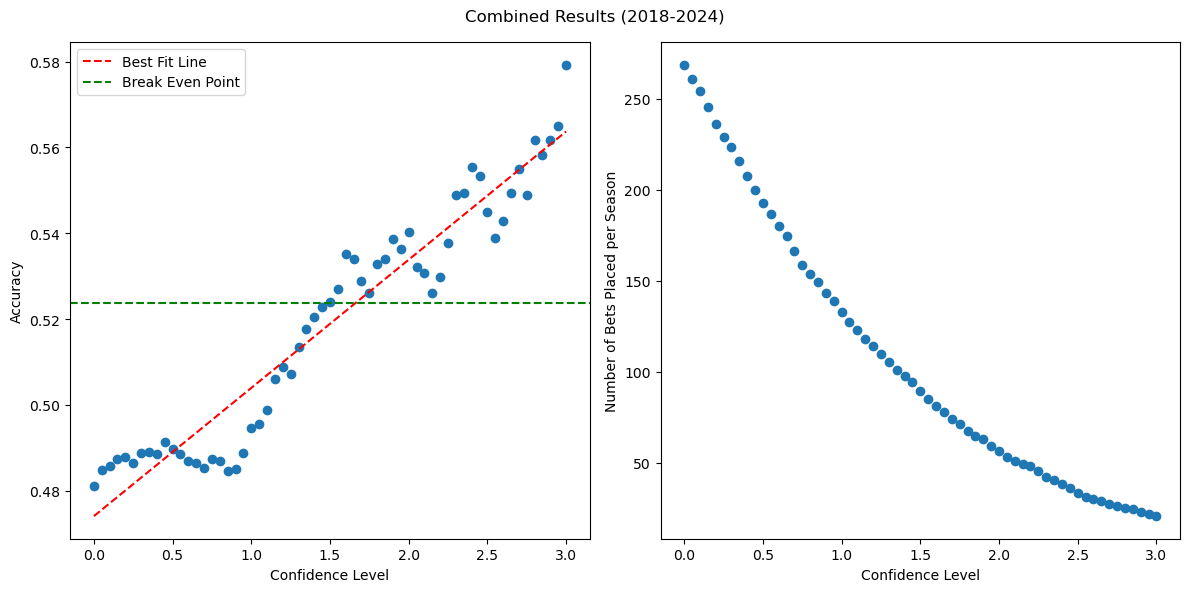

In [59]:
all_results = {}

for res in (res_2018 + res_2019 + res_2020 + res_2021 + res_2022 + res_2023 + res_2024):
    if res[0] not in all_results:
        accuracy = res[1]
        num_games = res[2]
        all_results[res[0]] = (accuracy, num_games)
    else:
        num_games = all_results[res[0]][1] + res[2]
        accuracy = (all_results[res[0]][0] * all_results[res[0]][1] + res[1] * res[2]) / num_games
        all_results[res[0]] = (accuracy, num_games)

all_results = pd.DataFrame(all_results).transpose().reset_index()
all_results.columns = ["confidence", "accuracy", "num_games"]
all_results["num_games"] = all_results["num_games"] / 7

plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
x_vals = all_results["confidence"]
y_vals = all_results["accuracy"]
plt.scatter(x_vals, y_vals)
plt.xlabel("Confidence Level")
plt.ylabel("Accuracy")
coeffs = np.polyfit(x_vals, y_vals, 1)
plt.plot(x_vals, np.poly1d(coeffs)(x_vals), color = "red", linestyle = "--", label = "Best Fit Line")
plt.axhline(y = (110/(100+110)), color = "green", linestyle = "--", label = "Break Even Point")
plt.legend()

plt.subplot(1, 2, 2)
y_vals2 = all_results["num_games"]
plt.scatter(x_vals, y_vals2)
plt.xlabel("Confidence Level")
plt.ylabel("Number of Bets Placed per Season")

plt.suptitle("Combined Results (2018-2024)")
plt.tight_layout()
plt.show()